# Aula 3 — Análise de Mutações e Alterações Genéticas

Nesta aula aplicamos ferramentas de bioinformática para **detetar e classificar alterações genéticas** em embriões antes da implantação — um processo clínico chamado **Diagnóstico Genético Pré-implantação (DGP/PGT)**.

---

## O que é o PGT?

O **PGT (Preimplantation Genetic Testing)** permite analisar o DNA de embriões obtidos por FIV antes de serem transferidos para o útero. Existem três tipos principais:

| Tipo | Nome completo | O que deteta | Exemplo clínico |
|---|---|---|---|
| **PGT-M** | Monogénico | Mutação num gene específico herdada na família | Fibrose Quística, Huntington |
| **PGT-A** | Aneuploidia | Número errado de cromossomas inteiros | Trissomia 21 (Down), Monossomia X (Turner) |
| **PGT-SR** | Rearranjos estruturais | Inversões ou translocações cromossómicas | Translocação Robertsoniana |

---

## Estrutura da Aula

| Exercício | Tipo de PGT | O que vamos fazer |
|---|---|---|
| **Exercício 1** | PGT-M | Buscar gene no NCBI → alinhar com sequência mutada → classificar mutação → traduzir para proteína |
| **Exercício 2** | PGT-A + PGT-SR | Buscar cromossomas no NCBI → simular contagem de cópias → detetar rearranjos |

---

> **Pergunta inicial:** O vosso grupo está a testar o gene **BRCA1**. Uma mulher portadora da mutação tem ~72% de risco de desenvolver cancro da mama ao longo da vida. Que impacto tem um resultado positivo numa análise PGT-M para os progenitores? E para o embrião?


---

# Exercício 1 — PGT-M: Teste Monogénico

O PGT-M testa **mutações num gene específico** já conhecidas na família. Cada grupo vai analisar **todos os genes** associados à sua categoria de doença.

## Atribuição de genes por grupo

| Grupo | Categoria | Doenças | Genes a analisar |
|---|---|---|---|
| **1** | Doenças Autossómicas Recessivas | Fibrose Quística, Anemia Falciforme, Tay-Sachs, β-Talassémia, AME | `CFTR`, `HBB`, `HEXA`, `SMN1` |
| **2** | Doenças Autossómicas Dominantes | Huntington, Sínd. Marfan, Distrofia Miotónica, Neurofibromatose | `HTT`, `FBN1`, `DMPK`, `NF1` |
| **3** | Doenças ligadas ao cromossoma X | Duchenne, X Frágil, Hemofilia A e B | `DMD`, `FMR1`, `F8`, `F9` |
| **4** | Cancros hereditários | BRCA1/2 (Mama/Ovário), Sínd. Lynch | `BRCA1`, `BRCA2`, `MLH1`, `MSH2` |
| **5** | Doenças Metabólicas e de Armazenamento | Gaucher, PKU, Galactosemia, ALD | `GBA`, `PAH`, `GALT`, `ABCD1` |
| **6** | Condições Neurológicas e Neuromusculares | Charcot-Marie-Tooth, Osteogénese Imperfeita, Esclerose Tuberosa | `PMP22`, `MPZ`, `TSC1`, `TSC2` |

---

### O que vamos fazer com cada gene do grupo?

Para **cada gene** da lista, o pipeline completo é:

```
Para cada gene do grupo:
  1.1 → Buscar sequência de referência no NCBI e informações clínicas do grupo de genes
  1.2 → Alinhar com a sequência mutada (DNA)
        → Identificar tipo e posição da mutação
        → Confirmar por BLAST
  1.3 → Traduzir ambas as sequências para proteína
        → Alinhar as proteínas e visualizar alterações
        → Classificar o impacto (sinónima / missense / nonsense / frameshift)
  1.4 → Confirmar patogenicidade (ClinVar / OMIM)
```

O ficheiro `mutacoes_reais_genes.fasta` contém **uma sequência mutada por gene** — os IDs têm o formato `GENE_mutX` (ex: `CFTR_mut1`, `HBB_mut1`). O código percorre automaticamente todos os genes do vosso grupo.

---

**Como funciona a herança?**

- **Autossómica recessiva** — o embrião só é afetado se herdar **duas** cópias mutadas (uma de cada progenitor). Portadores (uma cópia) são saudáveis.
- **Autossómica dominante** — **uma** cópia mutada é suficiente para causar doença.
- **Ligada ao X** — o gene está no cromossoma X; os rapazes (XY) com uma cópia mutada são afetados; as raparigas (XX) podem ser portadoras.

> **Pergunta:** Para a categoria do vosso grupo, um embrião portador de uma mutação em *apenas um* dos genes seria implantado? Depende do padrão de herança e da doença específica?


---

## 1.1 — Buscar as Sequências dos Genes do Vosso Grupo no NCBI

O **NCBI (National Center for Biotechnology Information)** é a principal base de dados genómica do mundo, com mais de 200 milhões de sequências.

Neste passo vamos usar o **BioPython** para, **para cada gene da lista do grupo**:
0. Pesquisar o primeiro gene na lista no NCBI para comparar os dados obtidos.
1. Pesquisar o gene por nome na base de dados `nucleotide`
2. Descarregar a sequência de mRNA em formato **FASTA** — será esta sequência que alinhamos com a sequência mutada
3. Consultar informação clínica na base de dados `gene`

### Bases de dados relevantes

| Base de dados | Conteúdo | Uso |
|---|---|---|
| `nucleotide` | Sequências de DNA/RNA | Obter sequência de referência do gene |
| `gene` | Anotações funcionais e clínicas | Informação sobre a doença |
| `omim` | Catálogo de doenças mendelianas | Patogenicidade de variantes |
| `clinvar` | Variantes clínicas curadas | Confirmar se mutação é patogénica |

> ⚠️ **Importante:** Substitui `"o_teu_email@exemplo.com"` pelo teu email real antes de correr. O NCBI bloqueia scripts sem identificação.

> 💡 O dicionário `GENES_POR_GRUPO` define os genes de cada grupo. Altera apenas a variável `MEU_GRUPO` para o número do teu grupo (1 a 6).


In [1]:
# Instalar todos os pacotes necessários para a Aula 3
!pip install biopython pandas numpy matplotlib

In [2]:
# Importar todos os pacotes necessários

# Biopython — acesso ao NCBI e análise de sequências
from Bio import Entrez, SeqIO              # pesquisa e leitura de sequências
from Bio.Blast import NCBIWWW, NCBIXML     # BLAST online
from Bio import pairwise2                  # alinhamento local/global
from Bio.pairwise2 import format_alignment # formatação de alinhamentos
from Bio.Seq import Seq                    # manipulação de sequências

# Análise de dados e visualização
import pandas as pd                        # tabelas de dados
import numpy as np                         # cálculos numéricos
import matplotlib.pyplot as plt            # gráficos
import matplotlib.patches as mpatches


c:\Users\ssalazar\AppData\Local\anaconda3\Lib\site-packages\Bio\pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


## 1.1. Buscar sequência de referência no NCBI e informações clínicas do grupo de genes

### 1.1.1 Defnine o teu grupo

In [3]:
# ──────────────────────────────────────────────
# GENES POR GRUPO
# ──────────────────────────────────────────────

GENES_POR_GRUPO = {
    1: ["CFTR", "HBB", "HEXA", "SMN1"],        # Autossómicas Recessivas
    2: ["HTT",  "FBN1", "DMPK", "NF1"],         # Autossómicas Dominantes
    3: ["DMD",  "FMR1", "F8",   "F9"],           # Ligadas ao X
    4: ["BRCA1", "BRCA2","MLH1", "MSH2"],         # Cancros hereditários
    5: ["GBA",  "PAH",  "GALT", "ABCD1"],        # Metabólicas
    6: ["PMP22", "MPZ",  "TSC1", "TSC2"],         # Neurológicas
}

# ──────────────────────────────────────────────
# Escolhe o teu grupo
# ──────────────────────────────────────────────

MEU_GRUPO = 5 # Altera para o número do teu grupo (1–6)
genes_meu_grupo = GENES_POR_GRUPO[MEU_GRUPO] 
print(f"Grupo {MEU_GRUPO} — genes a analisar: {genes_meu_grupo}\n")

Grupo 5 — genes a analisar: ['GBA', 'PAH', 'GALT', 'ABCD1']



### 1.2. Análise do primeiro gene do grupo

#### 1.2.1. Tirar a Sequência do gene no NCBI

Ao mesmo tempo verifica o resultado através da procura manual no NCBI: https://www.ncbi.nlm.nih.gov/

In [4]:
# ──────────────────────────────────────────────
# Retirar sequência de referência (mRNA) no NCBI
# ──────────────────────────────────────────────

# necessário 
Entrez.email = "o_teu_email@exemplo.com"  # OBRIGATÓRIO

# selecionar o primeiro gene
primeiro_gene = genes_meu_grupo[2]
print(f'Gene a investigar: {primeiro_gene}')

handle = Entrez.esearch(
    db="nucleotide",        # pesquisa os nucleótidos
    term=f"{primeiro_gene}[Gene Name] AND Homo sapiens[Organism] AND mRNA[Filter]",
    # X[Gene Name] filtra pelo nome do gene
    # Homo sapiens[Organism] restringe a sequências humanas
    # mRNA[Filter] pede especificamente a sequência de mRNA
    retmax=1                # apenas o primeiro resultado
)

print('Resultado da Entrez.esearch:')
print(handle)

#converter o HTTPResponse em algo legível
record = Entrez.read(handle)
print('Conversão dos dados:')
print(record)
#handle_gene.close()

#Queremos selecionar o primeiro IdList (referência única) do nosso gene
ref_id = record["IdList"][0]
print('ID do meu gene:')
print(ref_id)

#separador de visualização dos resultados
print(f"\n{'='*55}\n")

# Descarregar a sequência completa a partir do ID encontrado
handle = Entrez.efetch(
    db="nucleotide",       # mesma base de dados da pesquisa
    id=ref_id,             # ID do resultado (ex: "NM_000492.4")
    rettype="fasta",       # formato FASTA (cabeçalho + sequência pura)
    retmode="text"         # devolver como texto (em vez de XML)
)

print(f'Resultado da  Entrez.efetch - fasta: {handle}')

seq_record = SeqIO.read(handle, "fasta")

print(f"   ✅ Referência obtida : {seq_record.id}")
print(f"   🧬 Sequência        : {str(seq_record.seq[:60])}...")
print(f"   📏 Comprimento      : {len(seq_record.seq):,} bp")
handle.close()

Gene a investigar: GALT
Resultado da Entrez.esearch:
Conversão dos dados:
{'Count': '6', 'RetMax': '1', 'RetStart': '0', 'IdList': ['1889613967'], 'TranslationSet': [{'From': 'Homo sapiens[Organism]', 'To': '"Homo sapiens"[Organism]'}], 'TranslationStack': [{'Term': 'GALT[Gene Name]', 'Field': 'Gene Name', 'Count': '1667676', 'Explode': 'N'}, {'Term': '"Homo sapiens"[Organism]', 'Field': 'Organism', 'Count': '29545580', 'Explode': 'Y'}, 'AND', {'Term': 'mRNA[Filter]', 'Field': 'Filter', 'Count': '247893393', 'Explode': 'N'}, 'AND'], 'QueryTranslation': 'GALT[Gene Name] AND "Homo sapiens"[Organism] AND mRNA[Filter]'}
ID do meu gene:
1889613967


Resultado da  Entrez.efetch - fasta: <_io.TextIOWrapper encoding='UTF-8'>
   ✅ Referência obtida : NM_001258332.2
   🧬 Sequência        : AGATTTTCCAGCGGATCCCCCGGTGGCCTCATGTCGCGCAGTGGAACCGATCCTCAGCAA...
   📏 Comprimento      : 1,631 bp


## Questão:

- Porque tiramos a sequência de mRNA e não do DNA? 

#### 1.2.2. Informação clínica na base de dados Gene

In [5]:
# ──────────────────────────────────────────────
# Informação clínica via OMIM (usando esummary + elink)
# ──────────────────────────────────────────────

# Obter Gene DB ID (necessário para OMIM)
handle = Entrez.esearch(
    db="gene",              # base de dados "gene", diferente de "nucleotide"
    term=f"{primeiro_gene}[Gene Name] AND Homo sapiens[Organism]",
    retmax=1
)
record_gene = Entrez.read(handle)
handle.close()


gene_db_id = record_gene["IdList"][0]
print(f"   🧬 Gene DB ID: {gene_db_id}")


# Informação clínica via OMIM 
handle = Entrez.elink(      # Faz link entre bases de dados
    dbfrom="gene",          # partimos da base "gene"
    db="omim",              # queremos links para o OMIM
    id=gene_db_id           # Gene DB ID (não o ref_id!)
)
links = Entrez.read(handle)
handle.close()

if links[0]["LinkSetDb"]:      # verifica se existem links para o OMIM
    print(f"\n   🏥 OMIM — Doenças associadas:")
    for linkset in links[0]["LinkSetDb"]:        # percorre cada conjunto de links
        for link in linkset["Link"]:             # percorre cada link individual
            omim_id = link["Id"]                 # extrai o ID OMIM da entrada

            handle = Entrez.esummary(            # pede o resumo da entrada OMIM
                db="omim",                       # base de dados OMIM
                id=omim_id                       # ID da doença/fenótipo
            )
            summary = Entrez.read(handle)        # lê o resumo em formato dicionário
            handle.close()                       # fecha a ligação

            titulo = summary[0].get("Title", "N/A")  # extrai o título (ou "N/A" se ausente)
            print(f"      OMIM {omim_id}: {titulo}")
            print(f"      🔗 https://omim.org/entry/{omim_id}")  # link direto para a entrada OMIM


   🧬 Gene DB ID: 2592

   🏥 OMIM — Doenças associadas:
      OMIM 606999: GALACTOSE-1-PHOSPHATE URIDYLYLTRANSFERASE; GALT
      🔗 https://omim.org/entry/606999
      OMIM 230400: GALACTOSEMIA I; GALAC1
      🔗 https://omim.org/entry/230400


### 1.2. Análise para todos os genes do grupo
- Guarda as sequências

In [6]:
# Dicionário para guardar as referências — será reutilizado nos exercícios seguintes

referencias = {}  # gene_nome → SeqRecord da sequência de referência

for gene_nome in genes_meu_grupo:

    #Separador visual
    print(f"\n{'='*55}")
    print(f"🔍 Gene: {gene_nome}")
    print(f"{'='*55}")
    
    # ── 1. Buscar sequência de referência (mRNA) no NCBI ─────
    handle = Entrez.esearch(
        db="nucleotide",       
        term=f"{gene_nome}[Gene Name] AND Homo sapiens[Organism] AND mRNA[Filter]",
        retmax=1               
    )
    record_nuc = Entrez.read(handle)
    handle.close()
    
    ref_id = record_nuc["IdList"][0]
    print(f"   ID nucleotide: {ref_id}")
    
    # Descarregar a sequência em formato FASTA
    handle = Entrez.efetch(
        db="nucleotide",
        id=ref_id,
        rettype="fasta",      
        retmode="text"
    )
    seq_record = SeqIO.read(handle, "fasta")
    handle.close()
    
    # Guardar no dicionário para uso posterior
    referencias[gene_nome] = seq_record

    print(f"   ✅ Referência obtida : {seq_record.id}")
    print(f"   🧬 Sequência        : {str(seq_record.seq[:60])}...")
    print(f"   📏 Comprimento      : {len(seq_record.seq):,} bp")
    
    # ── 2. Obter Gene DB ID (necessário para OMIM) ───────────
    handle = Entrez.esearch(
        db="gene",              
        term=f"{gene_nome}[Gene Name] AND Homo sapiens[Organism]",
        retmax=1
    )
    record_gene = Entrez.read(handle)
    handle.close()
        
    gene_db_id = record_gene["IdList"][0]
    print(f"   🧬 Gene DB ID: {gene_db_id}")
    
    
    # ── 3. Informação clínica via OMIM ────────────────────────
    handle = Entrez.elink(
        dbfrom="gene",          # partimos da base "gene"
        db="omim",              # queremos links para o OMIM
        id=gene_db_id           # Gene DB ID (não o ref_id!)
    )
    links = Entrez.read(handle)
    handle.close()
    
    if links[0]["LinkSetDb"]:
        print(f"\n   🏥 OMIM — Doenças associadas:")
        for linkset in links[0]["LinkSetDb"]:
            for link in linkset["Link"]:
                omim_id = link["Id"]
                handle = Entrez.esummary(db="omim", id=omim_id)
                summary = Entrez.read(handle)
                handle.close()
                titulo = summary[0].get("Title", "N/A")
                print(f"      OMIM {omim_id}: {titulo}")
                print(f"      🔗 https://omim.org/entry/{omim_id}")




🔍 Gene: GBA
   ID nucleotide: 1650801318
   ✅ Referência obtida : NM_001171811.2
   🧬 Sequência        : ATCCTGCCTTCAGAGTCTTACTGCGCGGGGCCCCAGTCTCCAGTCCCGCCCAGGCGCCTT...
   📏 Comprimento      : 2,161 bp
   🧬 Gene DB ID: 2629

   🏥 OMIM — Doenças associadas:
      OMIM 608013: GAUCHER DISEASE, PERINATAL LETHAL
      🔗 https://omim.org/entry/608013
      OMIM 606463: GLUCOSIDASE, BETA, ACID; GBA
      🔗 https://omim.org/entry/606463
      OMIM 231005: GAUCHER DISEASE, TYPE IIIC; GD3C
      🔗 https://omim.org/entry/231005
      OMIM 231000: GAUCHER DISEASE, TYPE III; GD3
      🔗 https://omim.org/entry/231000
      OMIM 230900: GAUCHER DISEASE, TYPE II; GD2
      🔗 https://omim.org/entry/230900
      OMIM 230800: GAUCHER DISEASE, TYPE I; GD1
      🔗 https://omim.org/entry/230800
      OMIM 168600: PARKINSON DISEASE, LATE-ONSET; PD
      🔗 https://omim.org/entry/168600
      OMIM 127750: DEMENTIA, LEWY BODY; DLB
      🔗 https://omim.org/entry/127750

🔍 Gene: PAH
   ID nucleotide: 1676332825

## Questões

1. Qual é o **maior** e o **menor** gene (em bp) do vosso grupo?
2. A informação clínica retornada menciona a doença associada a cada gene? 

---

## 1.3 — Alinhamento DNA: Sequência Mutada vs Referência (para todos os genes)

O ficheiro `mutacoes_reais_genes.fasta` contém **uma sequência mutada por gene**, com IDs no formato `GENE_mut1` (ex: `CFTR_mut1`).

Os objectivos do código:
- Carrega a sequência mutada do ficheiro FASTA
- Alinha com a sequência de referência (Smith-Waterman)
- Lista todas as mutações por posição com o tipo (SNP / INSERÇÃO / DELEÇÃO)
- Corre o BLAST online para confirmação

### O que é um alinhamento?

Um **alinhamento de sequências** coloca dois fragmentos de DNA lado a lado para identificar **semelhanças e diferenças**:

```
Referência:  ATGCAGTACGTACGATCG
Mutada:      ATGCAGT-CGTACGATCG   ← deleção de A na posição 8
             |||||||  |||||||||||||
```

### Tipos de alinhamento

| Algoritmo | Tipo | Uso |
|---|---|---|
| **Smith-Waterman** | Local | Encontrar a região de maior similaridade (ideal para sequências de comprimentos diferentes) |
| **Needleman-Wunsch** | Global | Alinhar as sequências completas de ponta a ponta |
| **BLAST** | Heurístico | Pesquisa rápida em bases de dados enormes |

### Parâmetros de pontuação (*scoring*)

| Parâmetro | Valor | Significado |
|---|---|---|
| `match` | +2 | Prémio por base igual |
| `mismatch` | −1 | Penalização por substituição |
| `gap open` | −2 | Penalização por abrir um gap |
| `gap extend` | −0.5 | Penalização por cada posição adicional no gap |

---

### 1.4 — Alinhamento local + identificação de mutações por posição


In [7]:

FICHEIRO_FASTA  = "mutacoes_reais_genes.fasta"  # ficheiro com as sequências mutadas

# ──────────────────────────────────────────────
# Carregar TODAS as sequências mutadas do FASTA
# ──────────────────────────────────────────────
todas_mutadas = {rec.id: rec for rec in SeqIO.parse(FICHEIRO_FASTA, "fasta")}
print(f"Sequências mutadas carregadas: {list(todas_mutadas.keys())}\n")

# Dicionário para guardar as mutações encontradas — reutilizado na secção 1.3
resultados_mutacoes = {}  # gene_nome → {"mutada": SeqRecord, "mutacoes": [...], "n": int}

for gene_nome in genes_meu_grupo:
    print(f"\n{'='*60}")
    print(f"🧬 Gene: {gene_nome}")
    print(f"{'='*60}")

    # ── 1. Encontrar a sequência mutada ───────────────────────
    mutada = None
    for seq_id, seq_rec in todas_mutadas.items():
        if gene_nome in seq_id:
            mutada = seq_rec
            break

    if mutada is None:
        print(f"   ⚠️  Sequência mutada de {gene_nome} não encontrada no FASTA!")
        continue

    print(f"   ✅ Sequência mutada  : {mutada.id}  ({len(mutada.seq):,} bp)")

    # ── 2. Obter sequência de referência (já carregada em 1.1) ─
    if gene_nome not in referencias:
        print(f"   ⚠️  Referência de {gene_nome} não encontrada. Corre o exercício 1.1 primeiro.")
        continue

    referencia = referencias[gene_nome]
    print(f"   ✅ Sequência ref     : {referencia.id}  ({len(referencia.seq):,} bp)")

    # ── 3. Alinhamento local (Smith-Waterman) ─────────────────
    print("\n   📐 A calcular alinhamento local (Smith-Waterman)...")
    alinhamentos = pairwise2.align.localms(
        str(mutada.seq),
        str(referencia.seq),
        2,     # match
        -1,    # mismatch
        -2,    # gap open
        -0.5   # gap extend
    )

    melhor          = alinhamentos[0]
    seq_alin_mutada = melhor.seqA
    seq_alin_ref    = melhor.seqB
    score           = melhor.score

    # Calcular % identidade
    matches    = sum(a == b for a, b in zip(seq_alin_mutada, seq_alin_ref) if a != '-' and b != '-')
    total      = sum(1     for a, b in zip(seq_alin_mutada, seq_alin_ref) if a != '-' and b != '-')
    identidade = (matches / total) * 100 if total > 0 else 0

    print(f"   📊 Alignment Score  : {score:.1f}")
    print(f"   📊 % Identidade     : {identidade:.2f}%")

    # ── 4. Localizar mutações por posição ─────────────────────
    print(f"\n   🧬 Mutações encontradas:")
    print(f"   {'Posição':<10} {'Ref':<6} {'Mutada':<6} {'Tipo'}")
    print("   " + "-" * 36)

    posicao_real = 0
    mutacoes_lista = []

    for a, b in zip(seq_alin_mutada, seq_alin_ref):
        if b != '-':
            posicao_real += 1
        if a != b:
            tipo = "INSERÇÃO" if b == '-' else "DELEÇÃO" if a == '-' else "SNP"
            mutacoes_lista.append((posicao_real, b, a, tipo))
            print(f"   {posicao_real:<10} {b:<6} {a:<6} {tipo}")

    if not mutacoes_lista:
        print("   ✅ Nenhuma mutação — sequências idênticas!")
    else:
        print(f"\n   Total de diferenças: {len(mutacoes_lista)}")

    # Guardar para a secção 1.3
    resultados_mutacoes[gene_nome] = {
        "mutada"    : mutada,
        "mutacoes"  : mutacoes_lista,
        "n"         : len(mutacoes_lista),
        "identidade": identidade,
        "score"     : score,
    }

    # ── 5. BLAST online (confirmar) ───────────────────────────
    print("\n   🌐 A correr BLAST online (pode demorar 1-2 min)...")
    result_handle = NCBIWWW.qblast(
        program      = "blastn",
        database     = "nt",
        sequence     = str(mutada.seq),
        hitlist_size = 5
    )
    blast_records = NCBIXML.read(result_handle)

    print(f"\n   {'Hit':<38} {'E-value':<14} {'Score':<8} {'Ident.'}")
    print("   " + "-" * 72)
    for aln in blast_records.alignments[:5]:
        hsp      = aln.hsps[0]
        id_pct   = (hsp.identities / hsp.align_length) * 100
        print(f"   {aln.title[:36]:<38} {hsp.expect:<14.2e} {hsp.score:<8} {id_pct:.1f}%")

print("\n\n✅ Alinhamento DNA concluído para todos os genes.")


Sequências mutadas carregadas: ['CFTR|Referencia|Fibrose', 'HBB|Referencia|Anemia', 'HEXA|Mutado', 'SMN1|Referencia|nan', 'HTT|Referencia|Huntington', 'FBN1|Referencia|Marfan', 'DMPK|Mutado', 'NF1|Referencia|nan', 'DMD|Mutado', 'FMR1|Mutado', 'F8|Referencia|Hemofilia', 'F9|Referencia|nan', 'BRCA1|Referencia|BRCA1', 'BRCA2|Referencia|BRCA2', 'MLH1|Referencia|Lynch', 'MSH2|Referencia|nan', 'GBA|Referencia|Gaucher', 'PAH|Referencia|Fenilcetonúria', 'GALT|Referencia|Galactosemia', 'ABCD1|Referencia|nan', 'PMP22|Referencia|Charcot-Marie-Tooth', 'MPZ|Referencia|Demyelinating', 'TSC1|Referencia|Tuberous', 'TSC2|Referencia|nan']


🧬 Gene: GBA
   ✅ Sequência mutada  : GBA|Referencia|Gaucher  (2,161 bp)
   ✅ Sequência ref     : NM_001171811.2  (2,161 bp)

   📐 A calcular alinhamento local (Smith-Waterman)...
   📊 Alignment Score  : 4322.0
   📊 % Identidade     : 100.00%

   🧬 Mutações encontradas:
   Posição    Ref    Mutada Tipo
   ------------------------------------
   ✅ Nenhuma mutação — seq

#### ✏️ Questões — Exercício 1.2.1

1. Qual dos genes do vosso grupo tem a **maior % de identidade** com a referência? E o **menor**? O que pode explicar essa diferença?
2. Que tipos de mutações foram encontradas (SNP, inserção, deleção)? Em que genes?
3. Algum gene tem **mais do que uma mutação**? Uma acumulação de mutações é clinicamente mais grave?
4. Uma **deleção de 1 base** causa normalmente mais estragos do que uma **substituição**. Porquê? (Pensa no código genético e na grelha de leitura)

---

### 1.2.2 — Confirmação por BLAST online

O **BLAST** do NCBI compara cada sequência mutada contra **todas as sequências conhecidas** na base de dados `nt`.

| E-value | Interpretação |
|---|---|
| < 1e-50 | Hit muito significativo — sequência muito similar |
| 1e-10 a 1e-50 | Hit significativo |
| > 0.01 | Provavelmente acaso |

> **Pergunta:** Os hits do BLAST confirmam que as sequências mutadas pertencem ao gene correto? Existe algum hit surpresa (outro organismo, outra região do genoma)?


---

## 1.3 — Consequência da Mutação: Tradução e Alinhamento Proteico

Identificámos mutações ao nível do DNA. Agora precisamos perceber o que acontece à **proteína** codificada por esse gene.

### Do DNA à Proteína — Dogma Central

```
DNA (gene)  →  mRNA (transcrição)  →  Proteína (tradução)
```

O DNA é transcrito em mRNA, traduzido em proteína usando o **código genético** — trios de bases (**codões**) que codificam cada aminoácido.

### Tipos de mutação e impacto proteico

| Tipo de mutação | Definição | Impacto na proteína |
|---|---|---|
| **Sinónima (Silent)** | Substituição que **não altera** o aminoácido | Nenhum — proteína idêntica |
| **Missense** | Substituição que **altera** o aminoácido | Proteína com aa diferente — pode ser patogénica |
| **Nonsense** | Substituição que cria **stop codon prematuro** | Proteína truncada — geralmente patogénica |
| **Frameshift** | Inserção/deleção que **desloca a grelha de leitura** | Sequência de aa completamente alterada |

> **Porquê o frameshift é tão grave?** Imagine a frase `O CÃO VIU O RÃO`. Inserindo uma letra na posição 2: `OA CÃO VIU O RÃO` → o sentido perde-se completamente a partir daí.

---

### 1.3.1 — Tradução + Alinhamento proteico com visualização das alterações

Para **cada gene do grupo**, o código:
1. Traduz a sequência de referência e a sequência mutada para proteína
2. Alinha as duas proteínas (**Needleman-Wunsch** global — ideal para sequências do mesmo comprimento)
3. Gera uma **visualização por blocos** das alterações, ao estilo de um alinhamento múltiplo:

```
Ref    MALSRQAQTPSQAL...QFLNRLTQLAP
       ||||||||||||||||   |||| ||||
Mut    MALSRQAQTPSQAL...-QFLNXLTQLAP
                          ↑ missense na posição 120 (R→X)
```
4. Apresenta um **resumo tabular** das alterações para todos os genes do grupo



🔬 ANÁLISE PROTEICA — GBA

  🔤 TRADUÇÃO PARA AMINOÁCIDOS
  ──────────────────────────────────────────────────
   ⚠️  Referência: cortados 1 bp para alinhar codões
   ⚠️  Mutada: cortados 1 bp para alinhar codões
  Proteína REF    (   47 aa): ILPSESYCAGPQSPVPPRRLCRLRWDFVLPPVGAAVSLRRRCPPLHP
  Proteína MUT    (   47 aa): ILPSESYCAGPQSPVPPRRLCRLRWDFVLPPVGAAVSLRRRCPPLHP

  ↔️  Comprimentos iguais

  📐 ALINHAMENTO PROTEICO (Needleman-Wunsch global)
  ──────────────────────────────────────────────────
  Alignment Score  : 94.0
  % Identidade aa  : 100.00%

  ────────────────────────────────────────────────────────────
  Alinhamento proteico — GBA
  ────────────────────────────────────────────────────────────
  Ref [    1]  ILPSESYCAGPQSPVPPRRLCRLRWDFVLPPVGAAVSLRRRCPPLHP
           |||||||||||||||||||||||||||||||||||||||||||||||
  Mut [    1]  ILPSESYCAGPQSPVPPRRLCRLRWDFVLPPVGAAVSLRRRCPPLHP

  📋 ALTERAÇÕES NA PROTEÍNA:
  Posição aa   Ref      Mutada   Tipo
  ───────────────────────────────────

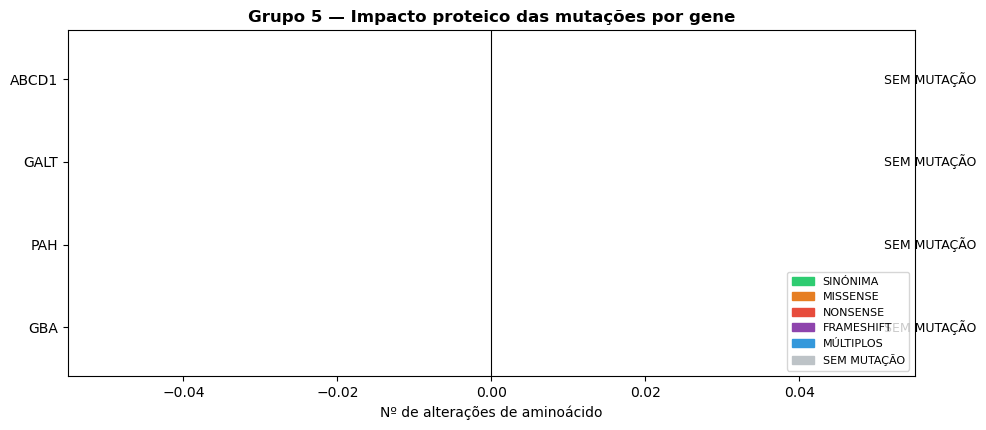


✅ Gráfico guardado: proteinas_grupo5.png


In [8]:


# ──────────────────────────────────────────────────────────────
# FUNÇÕES AUXILIARES
# ──────────────────────────────────────────────────────────────

def traduzir(seq, nome):
    """Traduz nucleótidos → aminoácidos; lida com comprimentos não múltiplos de 3."""
    seq_obj  = Seq(str(seq))
    resto    = len(seq_obj) % 3
    if resto != 0:
        seq_obj = seq_obj[:-resto]
        print(f"   ⚠️  {nome}: cortados {resto} bp para alinhar codões")
    return seq_obj.translate(to_stop=True)


def visualizar_alinhamento_proteico(prot_alin_ref, prot_alin_mut, gene_nome, largura=60):
    """
    Imprime o alinhamento proteico em blocos de `largura` caracteres,
    marcando as diferenças com '^' na linha do meio.
    """
    print(f"\n  {'─'*largura}")
    print(f"  Alinhamento proteico — {gene_nome}")
    print(f"  {'─'*largura}")

    for inicio in range(0, len(prot_alin_ref), largura):
        bloco_ref = prot_alin_ref[inicio:inicio+largura]
        bloco_mut = prot_alin_mut[inicio:inicio+largura]

        # Linha de marcadores
        marcadores = ""
        for r, m in zip(bloco_ref, bloco_mut):
            if r == m:
                marcadores += "|"
            elif r == '-' or m == '-':
                marcadores += "Δ"   # gap (inserção/deleção)
            else:
                marcadores += "✕"   # missense

        pos_ini = inicio + 1
        print(f"  Ref [{pos_ini:>5}]  {bloco_ref}")
        print(f"           {marcadores}")
        print(f"  Mut [{pos_ini:>5}]  {bloco_mut}")
        print()


def gerar_grafico_mutacoes(resumo_df, grupo_num):
    """
    Gráfico de barras horizontais: nº de alterações por gene,
    colorido por tipo dominante de mutação.
    """
    if resumo_df.empty:
        return

    cores_tipo = {
        "SINÓNIMA"    : "#2ecc71",
        "MISSENSE"    : "#e67e22",
        "NONSENSE"    : "#e74c3c",
        "FRAMESHIFT"  : "#8e44ad",
        "MÚLTIPLOS"   : "#3498db",
        "SEM MUTAÇÃO" : "#bdc3c7",
    }

    fig, ax = plt.subplots(figsize=(10, max(3, len(resumo_df) * 1.1)))

    for i, row in resumo_df.iterrows():
        cor  = cores_tipo.get(row["Classificação"], "#95a5a6")
        bar  = ax.barh(row["Gene"], row["Nº Alterações aa"], color=cor,
                       edgecolor="white", linewidth=0.8)
        ax.text(row["Nº Alterações aa"] + 0.05, i,
                f"  {row['Classificação']}", va="center", fontsize=9)

    ax.axvline(x=0, color="black", linewidth=0.8)
    ax.set_xlabel("Nº de alterações de aminoácido")
    ax.set_title(f"Grupo {grupo_num} — Impacto proteico das mutações por gene", fontweight="bold")

    patches = [mpatches.Patch(color=c, label=l) for l, c in cores_tipo.items()]
    ax.legend(handles=patches, loc="lower right", fontsize=8)
    plt.tight_layout()
    plt.savefig(f"proteinas_grupo{grupo_num}.png", dpi=150)
    plt.show()
    print(f"\n✅ Gráfico guardado: proteinas_grupo{grupo_num}.png")


# ──────────────────────────────────────────────────────────────
# PIPELINE PRINCIPAL — loop por todos os genes do grupo
# ──────────────────────────────────────────────────────────────
resumo_proteinas = []  # linha por gene para a tabela final

for gene_nome in genes_meu_grupo:
    print(f"\n{'='*65}")
    print(f"🔬 ANÁLISE PROTEICA — {gene_nome}")
    print(f"{'='*65}")

    # Verificar se temos os dados dos exercícios anteriores
    if gene_nome not in referencias:
        print(f"   ⚠️  Referência de {gene_nome} não encontrada. Corre o exercício 1.1 primeiro.")
        continue
    if gene_nome not in resultados_mutacoes:
        print(f"   ⚠️  Dados de alinhamento de {gene_nome} não encontrados. Corre o exercício 1.2 primeiro.")
        continue

    referencia = referencias[gene_nome]
    mutada     = resultados_mutacoes[gene_nome]["mutada"]
    n_mut_dna  = resultados_mutacoes[gene_nome]["n"]

    # ── 1. Traduzir ambas as sequências ───────────────────────
    print("\n  🔤 TRADUÇÃO PARA AMINOÁCIDOS")
    print("  " + "─"*50)

    proteina_ref    = traduzir(referencia.seq, "Referência")
    proteina_mutada = traduzir(mutada.seq,     "Mutada")

    print(f"  Proteína REF    ({len(proteina_ref):>5} aa): {str(proteina_ref)[:70]}{'...' if len(proteina_ref) > 70 else ''}")
    print(f"  Proteína MUT    ({len(proteina_mutada):>5} aa): {str(proteina_mutada)[:70]}{'...' if len(proteina_mutada) > 70 else ''}")

    diff_comprimento = len(proteina_ref) - len(proteina_mutada)
    if diff_comprimento > 0:
        print(f"\n  ⛔ Stop codon prematuro! Proteína mutada é {diff_comprimento} aa mais curta")
    elif diff_comprimento < 0:
        print(f"\n  ➕ Proteína mutada é {abs(diff_comprimento)} aa mais longa")
    else:
        print("\n  ↔️  Comprimentos iguais")

    # ── 2. Alinhar as duas proteínas (Needleman-Wunsch global) ─
    print("\n  📐 ALINHAMENTO PROTEICO (Needleman-Wunsch global)")
    print("  " + "─"*50)

    alin_prot       = pairwise2.align.globalms(
        str(proteina_ref), str(proteina_mutada),
        2, -1, -2, -0.5
    )[0]
    prot_alin_ref   = alin_prot.seqA
    prot_alin_mut   = alin_prot.seqB
    score_prot      = alin_prot.score

    # % identidade proteica
    matches_p = sum(r == m for r, m in zip(prot_alin_ref, prot_alin_mut) if r != '-' and m != '-')
    total_p   = sum(1     for r, m in zip(prot_alin_ref, prot_alin_mut) if r != '-' and m != '-')
    id_prot   = (matches_p / total_p) * 100 if total_p > 0 else 0

    print(f"  Alignment Score  : {score_prot:.1f}")
    print(f"  % Identidade aa  : {id_prot:.2f}%")

    # ── 3. Visualização bloco a bloco ─────────────────────────
    visualizar_alinhamento_proteico(prot_alin_ref, prot_alin_mut, gene_nome, largura=60)

    # ── 4. Tabela de alterações por posição ───────────────────
    print("  📋 ALTERAÇÕES NA PROTEÍNA:")
    print(f"  {'Posição aa':<12} {'Ref':<8} {'Mutada':<8} {'Tipo'}")
    print("  " + "─" * 42)

    alteracoes = []
    pos_real   = 0

    for ref_aa, mut_aa in zip(prot_alin_ref, prot_alin_mut):
        if ref_aa != '-':
            pos_real += 1
        if ref_aa != mut_aa:
            tipo = "INSERÇÃO" if ref_aa == '-' else "DELEÇÃO" if mut_aa == '-' else "MISSENSE"
            alteracoes.append((pos_real, ref_aa, mut_aa, tipo))
            # Notação HGVS proteica: p.Arg120Trp
            print(f"  {pos_real:<12} {ref_aa:<8} {mut_aa:<8} {tipo}  (p.{ref_aa}{pos_real}{mut_aa})")

    if not alteracoes:
        print("  ✅ Proteína idêntica à referência — mutação DNA é SINÓNIMA")

    # ── 5. Classificação final da mutação ─────────────────────
    print("\n  📋 CLASSIFICAÇÃO FINAL:")
    if not alteracoes and n_mut_dna > 0:
        classificacao = "SINÓNIMA"
        print("  🟡 SINÓNIMA — altera nucleótido mas NÃO altera aminoácido")
    elif diff_comprimento > 0:
        classificacao = "NONSENSE" if n_mut_dna <= 2 else "FRAMESHIFT"
        print(f"  🔴 {classificacao} — proteína truncada ({abs(diff_comprimento)} aa perdidos)")
    elif any(t == "MISSENSE" for _, _, _, t in alteracoes):
        classificacao = "MISSENSE"
        print("  🟠 MISSENSE — substituição(ões) de aminoácido(s):")
        for pos, ref_aa, mut_aa, _ in alteracoes:
            if mut_aa not in ('-', ):
                print(f"     p.{ref_aa}{pos}{mut_aa}")
    else:
        classificacao = "MÚLTIPLOS" if alteracoes else "SEM MUTAÇÃO"

    resumo_proteinas.append({
        "Gene"              : gene_nome,
        "Mutações DNA"      : n_mut_dna,
        "Comprimento Ref (aa)": len(proteina_ref),
        "Comprimento Mut (aa)": len(proteina_mutada),
        "Δ comprimento (aa)": diff_comprimento,
        "Nº Alterações aa"  : len(alteracoes),
        "% Identidade aa"   : round(id_prot, 2),
        "Classificação"     : classificacao,
    })

# ──────────────────────────────────────────────────────────────
# TABELA RESUMO FINAL (todos os genes do grupo)
# ──────────────────────────────────────────────────────────────
print("\n" + "="*65)
print(f"📊 TABELA RESUMO — GRUPO {MEU_GRUPO}")
print("="*65)

df_resumo = pd.DataFrame(resumo_proteinas)
print(df_resumo.to_string(index=False))

# ──────────────────────────────────────────────────────────────
# GRÁFICO
# ──────────────────────────────────────────────────────────────
gerar_grafico_mutacoes(df_resumo, MEU_GRUPO)


In [9]:
# Pesquisa no ClinVar (record próprio)
handle = Entrez.esearch(
    db="clinvar",
    term=f"{primeiro_gene}[gene] AND pathogenic[clinical significance]",
    retmax=5
)
record_clinvar = Entrez.read(handle)  # ← nome diferente para não confundir
handle.close()

print(f"Variantes patogénicas encontradas: {record_clinvar['Count']}")

# Mostrar resumos
for var_id in record_clinvar["IdList"]:
    handle = Entrez.esummary(db="clinvar", id=var_id)
    summary = Entrez.read(handle, validate=False)
    handle.close()
    
    doc = summary["DocumentSummarySet"]["DocumentSummary"][0]
    print(f"\n── ClinVar {var_id} ──")
    print(f"   Título       : {doc.get('title', 'N/A')}")
    print(f"   Significância: {doc.get('clinical_significance', {}).get('description', 'N/A')}")
    print(f"   Link         : https://www.ncbi.nlm.nih.gov/clinvar/variation/{var_id}/")

Variantes patogénicas encontradas: 540

── ClinVar 4847463 ──
   Título       : NM_000155.4(GALT):c.260C>T (p.Pro87Leu)
   Significância: N/A
   Link         : https://www.ncbi.nlm.nih.gov/clinvar/variation/4847463/

── ClinVar 4819211 ──
   Título       : Single allele
   Significância: N/A
   Link         : https://www.ncbi.nlm.nih.gov/clinvar/variation/4819211/

── ClinVar 4817651 ──
   Título       : NM_000155.4(GALT):c.991_992del (p.Thr331fs)
   Significância: N/A
   Link         : https://www.ncbi.nlm.nih.gov/clinvar/variation/4817651/

── ClinVar 4817650 ──
   Título       : NM_000155.4(GALT):c.989C>T (p.Ala330Val)
   Significância: N/A
   Link         : https://www.ncbi.nlm.nih.gov/clinvar/variation/4817650/

── ClinVar 4817649 ──
   Título       : NM_000155.4(GALT):c.939G>A (p.Trp313Ter)
   Significância: N/A
   Link         : https://www.ncbi.nlm.nih.gov/clinvar/variation/4817649/


#### ✏️ Questões — Exercício 1.3

**Sobre a tradução:**
1. Qual dos genes do vosso grupo resultou numa proteína **mais curta** (stop codon prematuro)? Qual é a posição do stop prematuro?
2. A proteína truncada perde domínios funcionais importantes? (Dica: pesquisa no UniProt os domínios do gene em causa)

**Sobre o alinhamento proteico:**
3. No alinhamento por blocos, o que representa o símbolo `|`? E `✕`? E `Δ`?
4. Para as mutações MISSENSE encontradas, a substituição de aminoácido é **conservativa** (aminoácido com propriedades químicas semelhantes, e.g., Leu→Val) ou **não conservativa** (e.g., Arg→Trp)? Qual seria mais deletéria?

**Sobre o gráfico:**
5. Qual o gene com maior impacto ao nível proteico (maior número de alterações de aminoácido)? Corresponde ao gene com mais mutações no DNA?
6. Existe algum caso onde há mutações no DNA mas a proteína é idêntica (sinónima)? O que permite isso? (Pensa na degenerescência do código genético)

---

### 1.3.2 — Confirmação por BLASTx

O **BLASTx** traduz a sequência de nucleótidos nas 6 grelhas de leitura possíveis e compara com a base de dados de proteínas.

> 💡 **Tarefa:** Para o gene com maior impacto proteico no vosso grupo, vai a [https://blast.ncbi.nlm.nih.gov/](https://blast.ncbi.nlm.nih.gov/), seleciona **BLASTx**, cola a sequência mutada e compara os domínios identificados com os da proteína de referência. Houve perda de domínios funcionais?


---

## 1.4 — Confirmar a Patogenicidade da Mutação

Identificámos uma mutação. Mas nem toda a mutação é **patogénica** — algumas são variantes benignas da sequência normal (SNPs comuns na população).

Para confirmar a patogenicidade, usamos bases de dados clínicas curadas por especialistas:

| Base de dados | URL | O que procurar |
|---|---|---|
| **ClinVar** | [clinvar.ncbi.nlm.nih.gov](https://www.ncbi.nlm.nih.gov/clinvar/) | Classificação clínica da variante (Patogénica / Benigna / VUS) |
| **OMIM** | [omim.org](https://www.omim.org) | Doença associada ao gene e mutações causais conhecidas |
| **gnomAD** | [gnomad.broadinstitute.org](https://gnomad.broadinstitute.org) | Frequência da variante na população geral (variantes raras são mais provavelmente patogénicas) |
| **UniProt** | [uniprot.org](https://www.uniprot.org) | Impacto da mutação na função proteica |

### Classificação de variantes (ACMG/AMP Guidelines)

| Classificação | Significado |
|---|---|
| **Patogénica** | Causa provada da doença |
| **Provavelmente patogénica** | Evidência forte mas não conclusiva |
| **VUS** (Variante de Significado Incerto) | Evidência insuficiente |
| **Provavelmente benigna** | Provavelmente sem efeito clínico |
| **Benigna** | Não causa doença |

> ✏️ **Tarefa manual:** Pesquisa a mutação identificada no exercício 1.2.1 na base de dados **ClinVar**. Qual é a classificação clínica? Existe algum artigo científico associado?

> 💡 **Tip:** Usa a notação HGVS para pesquisar — por exemplo, para uma substituição na posição 185 do BRCA1: `NM_007294.4:c.185delAG`


---

# Exercício 2 — PGT-A e PGT-SR: Análise Cromossómica

Enquanto o PGT-M testa mutações em genes específicos, o **PGT-A** e o **PGT-SR** analisam a integridade dos **cromossomas inteiros**.

## Contexto clínico

- **PGT-A:** Deteta **aneuploidias** — número errado de cópias de um cromossoma (trissomia, monossomia). É a causa mais comum de insucesso em FIV e de abortos espontâneos no 1.º trimestre.
- **PGT-SR:** Deteta **rearranjos estruturais** — o cromossoma existe em número correto mas partes dele foram invertidas, duplicadas ou translocadas para outro cromossoma.

## Atribuição de síndromes por grupo

| Grupo | Síndrome | Cromossoma afetado | Tipo de alteração | Impacto clínico |
|---|---|---|---|---|
| **1** | Down Syndrome | Chr 21 | Trissomia (3 cópias) | Deficiência intelectual, cardiopatia congénita |
| **2** | Edwards Syndrome | Chr 18 | Trissomia (3 cópias) | Anomalias graves; maioria não sobrevive ao 1.º ano |
| **3** | Patau Syndrome | Chr 13 | Trissomia (3 cópias) | Malformações graves; maioria não sobrevive |
| **4** | Klinefelter Syndrome | Chr X (XXY) | Monossomia/Trissomia sexual | Infertilidade masculina, ginecomastia |
| **5** | Turner Syndrome | Chr X (XO) | Monossomia (1 cópia) | Baixa estatura, infertilidade feminina |
| **6** | Jacob's Syndrome | Chr Y (XYY) | Trissomia sexual | Geralmente assintomático; pode haver problemas de aprendizagem |

---

### Como é feita esta análise em laboratório?

Em contexto real, usa-se:
- **Array CGH** (Comparative Genomic Hybridization) ou **NGS** para contar cópias de cada cromossoma
- Os dados geram um **karyograma** numérico (número de cópias ao longo do genoma)

Neste exercício vamos **simular** esta análise: buscamos as sequências de referência dos cromossomas no NCBI e simulamos os números de cópias esperados para cada síndrome.

> **Pergunta:** Para um casal em que ambos os progenitores têm cariótipo normal (46,XX e 46,XY), qual a probabilidade de ter um embrião com Trissomia 21? Essa probabilidade aumenta com a idade materna? Porquê?


---

## 2.1 — Buscar Cromossomas no NCBI e Simular Contagem de Cópias

O código seguinte faz três análises em sequência:

**Passo 1 — Buscar as sequências de referência** (`GRCh38`, o genoma humano de referência mais recente)
- Para cada cromossoma relevante, pesquisa o NCBI e descarrega os primeiros 10 kb (para não sobrecarregar os servidores)

**Passo 2 — PGT-A: Simular contagem de cópias**
- Em ambiente real: dados de NGS são mapeados ao genoma e conta-se a cobertura por cromossoma
- Aqui: usamos o número de cópias esperado para cada síndrome (simulação)
- Resultado: diagnóstico de **Trissomia**, **Monossomia** ou **Normal**

**Passo 3 — PGT-SR: Detetar rearranjos estruturais**
- Divide a sequência de referência em 4 segmentos
- Calcula o **%GC** (percentagem de Guanina + Citosina) em cada segmento
- Uma variação elevada de GC% entre segmentos pode indicar uma inversão ou translocação (em dados reais, usaríamos mapas de cobertura de NGS)

**Passo 4 — Tabela resumo + Gráfico**
- Gera uma tabela com todos os resultados
- Cria um gráfico de barras com o número de cópias por cromossoma (vermelho = trissomia, laranja = monossomia, verde = normal)

> ⚠️ **Nota:** Altera a variável `Entrez.email` para o teu endereço antes de correr o código.


🔍 A buscar cromossomas no NCBI (GRCh38)...

📊 PGT-A — ANÁLISE DE ANEUPLOIDIA

🔬 Grupo 1 - Autossómica Recessiva — Cromossoma 21 (Down Syndrome)
   NCBI ID      : 2194972717
   Comprimento  : 10,000 bp (amostra 10kb)
   Cópias       : ⚠️  TRISSOMIA (n=3)
   Síndrome     : Down Syndrome (Trissomia)

🔬 Grupo 2 - Autossómica Dominante — Cromossoma 18 (Edwards Syndrome)
   NCBI ID      : 2713918602
   Comprimento  : 236 bp (amostra 10kb)
   Cópias       : ⚠️  TRISSOMIA (n=3)
   Síndrome     : Edwards Syndrome (Trissomia)

🔬 Grupo 3 - Ligada ao X — Cromossoma 13 (Patau Syndrome)
   NCBI ID      : 568815585
   Comprimento  : 10,000 bp (amostra 10kb)
   Cópias       : ⚠️  TRISSOMIA (n=3)
   Síndrome     : Patau Syndrome (Trissomia)

🔬 Grupo 4 - Cancros Hereditários — Cromossoma X (Klinefelter Syndrome)
   NCBI ID      : 2194974009
   Comprimento  : 10,000 bp (amostra 10kb)
   Cópias       : ✅ NORMAL (n=2)
   Síndrome     : Klinefelter Syndrome (XXY)

🔬 Grupo 5 - Metabólica — Cromossoma X (Turn

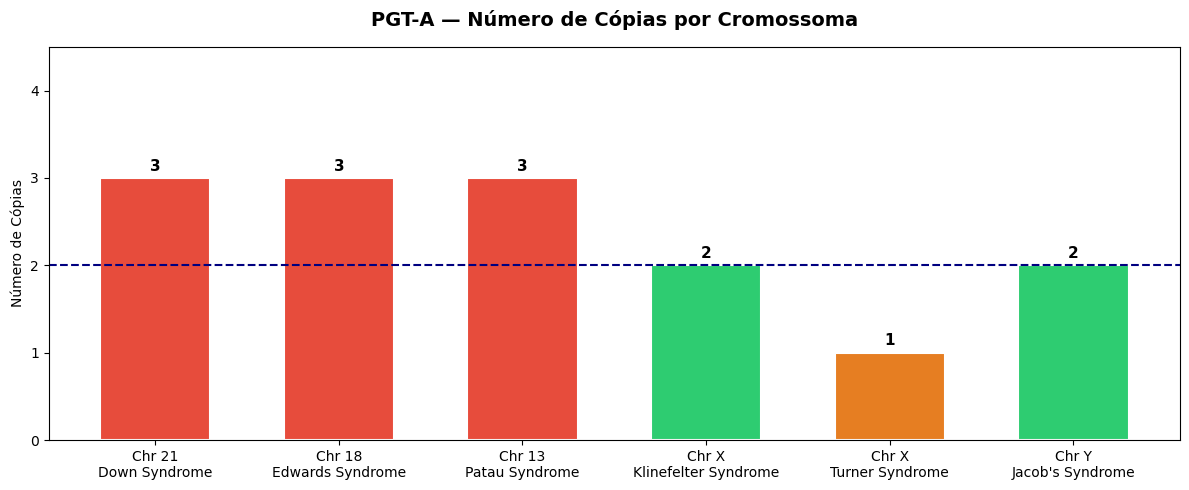


✅ Gráfico guardado como 'pgta_resultado.png'


In [10]:
from Bio import Entrez, SeqIO
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ──────────────────────────────────────────────
# CONFIGURAÇÃO
# ──────────────────────────────────────────────
Entrez.email = "o_teu_email@exemplo.com"

# Usamos hg38 (GRCh38) — mais recente e recomendado
GENOME_REF = "GRCh38"

# Grupos do exercício
CROMOSSOMAS = {
    "Grupo 1 - Autossómica Recessiva": {
        "chr": "21", "sindrome": "Down Syndrome",       "tipo": "Trissomia", "esperado": 3
    },
    "Grupo 2 - Autossómica Dominante": {
        "chr": "18", "sindrome": "Edwards Syndrome",    "tipo": "Trissomia", "esperado": 3
    },
    "Grupo 3 - Ligada ao X": {
        "chr": "13", "sindrome": "Patau Syndrome",      "tipo": "Trissomia", "esperado": 3
    },
    "Grupo 4 - Cancros Hereditários": {
        "chr": "X",  "sindrome": "Klinefelter Syndrome","tipo": "XXY",       "esperado": 2
    },
    "Grupo 5 - Metabólica": {
        "chr": "X",  "sindrome": "Turner Syndrome",     "tipo": "XO",        "esperado": 1
    },
    "Grupo 6 - Neurológica": {
        "chr": "Y",  "sindrome": "Jacob's Syndrome",    "tipo": "XYY",       "esperado": 2
    },
}

# ──────────────────────────────────────────────
# 1. BUSCAR SEQUÊNCIAS DE REFERÊNCIA NO NCBI
# ──────────────────────────────────────────────
print("🔍 A buscar cromossomas no NCBI (GRCh38)...\n")

def buscar_cromossoma_ncbi(numero_chr):
    """Busca a sequência de referência de um cromossoma no NCBI."""
    termo = f"Homo sapiens chromosome {numero_chr} {GENOME_REF} reference assembly"
    handle = Entrez.esearch(db="nucleotide", term=termo, retmax=1)
    record = Entrez.read(handle)
    handle.close()

    if not record["IdList"]:
        print(f"   ⚠️  Cromossoma {numero_chr} não encontrado!")
        return None

    ncbi_id = record["IdList"][0]
    handle = Entrez.efetch(
        db="nucleotide", id=ncbi_id,
        rettype="fasta", retmode="text",
        seq_start=1, seq_stop=10000  # primeiros 10kb para não sobrecarregar
    )
    seq = SeqIO.read(handle, "fasta")
    handle.close()
    return seq, ncbi_id

# ──────────────────────────────────────────────
# 2. PGT-A — CONTAR CÓPIAS DE CROMOSSOMAS
# ──────────────────────────────────────────────
print("=" * 60)
print("📊 PGT-A — ANÁLISE DE ANEUPLOIDIA")
print("=" * 60)

resultados_pgta = []

for grupo, info in CROMOSSOMAS.items():
    chr_num = info["chr"]
    print(f"\n🔬 {grupo} — Cromossoma {chr_num} ({info['sindrome']})")

    resultado = buscar_cromossoma_ncbi(chr_num)
    if resultado is None:
        continue

    seq, ncbi_id = resultado
    comprimento = len(seq.seq)

    # Simular número de cópias baseado no tipo de síndrome
    # (em ambiente real, isto viria de dados NGS/array CGH)
    copias_simuladas = info["esperado"]
    normal = 2  # diplóide normal

    if copias_simuladas > normal:
        status = f"⚠️  TRISSOMIA (n={copias_simuladas})"
        cor = "red"
    elif copias_simuladas < normal:
        status = f"⚠️  MONOSSOMIA (n={copias_simuladas})"
        cor = "orange"
    else:
        status = f"✅ NORMAL (n={copias_simuladas})"
        cor = "green"

    print(f"   NCBI ID      : {ncbi_id}")
    print(f"   Comprimento  : {comprimento:,} bp (amostra 10kb)")
    print(f"   Cópias       : {status}")
    print(f"   Síndrome     : {info['sindrome']} ({info['tipo']})")

    resultados_pgta.append({
        "Grupo"       : grupo,
        "Cromossoma"  : f"Chr {chr_num}",
        "Síndrome"    : info["sindrome"],
        "Tipo"        : info["tipo"],
        "Cópias"      : copias_simuladas,
        "Status"      : status.split("(")[0].strip(),
        "NCBI ID"     : ncbi_id
    })

# ──────────────────────────────────────────────
# 3. PGT-SR — DETETAR REARRANJOS ESTRUTURAIS
# ──────────────────────────────────────────────
print("\n" + "=" * 60)
print("🔬 PGT-SR — ANÁLISE DE REARRANJOS ESTRUTURAIS")
print("=" * 60)

def analisar_rearranjos(seq, chr_num):
    """
    Deteta potenciais inversões/translocações comparando
    padrões na sequência de referência.
    """
    seq_str = str(seq.seq).upper()
    tamanho  = len(seq_str)

    # Dividir em janelas para análise de rearranjos
    janela = tamanho // 4
    segmentos = [seq_str[i:i+janela] for i in range(0, tamanho, janela)]

    print(f"\n   Cromossoma {chr_num} — {tamanho:,} bp analisados")
    print(f"   {'Segmento':<12} {'Tamanho':<12} {'GC%':<10} {'Status'}")
    print("   " + "-" * 50)

    anomalias = []
    gc_conteudos = []

    for i, seg in enumerate(segmentos[:4]):
        gc = (seg.count("G") + seg.count("C")) / len(seg) * 100 if seg else 0
        gc_conteudos.append(gc)

        # Sinalizar se GC% anómalo (pode indicar rearranjo)
        if gc < 30 or gc > 60:
            stat = "⚠️  GC% anómalo"
            anomalias.append(i)
        else:
            stat = "✅ Normal"

        print(f"   Segmento {i+1:<4} {len(seg):<12,} {gc:<10.1f} {stat}")

    # Verificar variação entre segmentos (possível indicador de rearranjo)
    variacao_gc = np.std(gc_conteudos)
    if variacao_gc > 10:
        print(f"\n   ⚠️  Alta variação de GC% entre segmentos (σ={variacao_gc:.1f})")
        print(f"      → Possível INVERSÃO ou TRANSLOCAÇÃO")
    else:
        print(f"\n   ✅ GC% estável (σ={variacao_gc:.1f}) — sem rearranjos evidentes")

    return anomalias

for grupo, info in CROMOSSOMAS.items():
    chr_num = info["chr"]
    resultado = buscar_cromossoma_ncbi(chr_num)
    if resultado:
        seq, _ = resultado
        analisar_rearranjos(seq, chr_num)

# ──────────────────────────────────────────────
# 4. TABELA RESUMO
# ──────────────────────────────────────────────
print("\n" + "=" * 60)
print("📋 TABELA RESUMO — PGT-A")
print("=" * 60)
df = pd.DataFrame(resultados_pgta)
print(df[["Cromossoma", "Síndrome", "Tipo", "Cópias", "Status"]].to_string(index=False))

# ──────────────────────────────────────────────
# 5. GRÁFICO — NÚMERO DE CÓPIAS POR CROMOSSOMA
# ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

cores = {
    "⚠️  TRISSOMIA" : "#e74c3c",
    "⚠️  MONOSSOMIA": "#e67e22",
    "✅ NORMAL"     : "#2ecc71"
}

labels = [f"Chr {r['Cromossoma'].split()[1]}\n{r['Síndrome']}" for r in resultados_pgta]
copias = [r["Cópias"] for r in resultados_pgta]
status = [r["Status"] for r in resultados_pgta]
bar_cores = [cores.get(s, "#3498db") for s in status]

bars = ax.bar(labels, copias, color=bar_cores, edgecolor="white", linewidth=1.5, width=0.6)
ax.axhline(y=2, color="navy", linestyle="--", linewidth=1.5, label="Normal (n=2)")

for bar, val in zip(bars, copias):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            str(val), ha="center", va="bottom", fontweight="bold", fontsize=11)

# Legenda
#patches = [mpatches.Patch(color=c, label=l) for l, c in cores.items()]
#ax.legend(handles=patches, loc="upper right")

ax.set_title("PGT-A — Número de Cópias por Cromossoma", fontsize=14, fontweight="bold", pad=15)
ax.set_ylabel("Número de Cópias")
ax.set_ylim(0, 4.5)
ax.set_yticks([0, 1, 2, 3, 4])
plt.tight_layout()
plt.savefig("pgta_resultado.png", dpi=150)
plt.show()
print("\n✅ Gráfico guardado como 'pgta_resultado.png'")


#### ✏️ Questões — Exercício 2

**PGT-A:**
1. Para o cromossoma do vosso grupo, qual é o número de cópias simulado? Corresponde ao esperado para a síndrome atribuída?
2. No gráfico gerado, identifica quais os grupos com resultado ANORMAL. Que cores foram atribuídas e porquê?
3. Um embrião com Trissomia 21 deverá ser implantado? Que fatores éticos e clínicos devem ser considerados?

**PGT-SR:**
4. A análise de GC% detetou anomalias nos segmentos do cromossoma? Em que segmento(s)?
5. Porque é que uma variação alta de GC% entre segmentos pode indicar uma translocação? (Pensa nas regiões heterocromáticas dos cromossomas)
6. O método de GC% é suficiente para detetar rearranjos estruturais numa situação clínica real? Que técnicas seriam mais adequadas?


---

# Conclusões da Aula 3

Respondam em grupo às seguintes questões de síntese:

**1. PGT-M vs PGT-A:** Qual dos dois testes (PGT-M ou PGT-A) é mais informativo? Faz sentido fazê-los em simultâneo? Porquê?

**2. Interpretação clínica da mutação encontrada:**
   - A mutação que analisaram é patogénica, benigna ou de significado incerto?
   - Que bases de dados consultaram para confirmar?
   - Como classificariam a mutação usando as categorias ACMG?

**3. Decisão clínica:**
   - Com base nos resultados do PGT-M (Exercício 1) e do PGT-A (Exercício 2), que embriões recomendariam para implantação?
   - E se o único embrião disponível tivesse uma mutação de significado incerto (VUS)? O que aconselhavam ao casal?

**4. Limitações das ferramentas:**
   - O alinhamento com Smith-Waterman é adequado para sequências muito longas (>10 kb)? Que alternativa usariam?
   - O método de GC% para detetar rearranjos é clinicamente válido? Que tecnologia substitui?

---

> 🔭 **Na próxima aula:** Vamos aprofundar a análise de variantes usando ferramentas de anotação automática (VEP — Variant Effect Predictor) e integrar os dados genómicos com dados de expressão génica.
